In [1]:
from torch import torch, nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import random
import numpy as np
from skimage.feature import hog

In [ ]:
# setup
isLocal = True
isColab = False

HOG_FEATURES = False
AUGMENTATION = False

BATCH_SIZE = 128
EPOCHS = 30
SWA_START = 0
SWA_LR = 5e-5
LR = 1e-3
L2_REGULARIZATION = 2e-5
COSINE_ETA_MIN=5e-5
LABEL_SMOOTHING=0.05
EARLY_STOPPING_PATIENCE=15


In [ ]:

if isLocal:
    SAVE_PATH = './best_model_mlp.pth'
elif isColab:
    from google.colab import drive
    import os
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/MSAI/AI-600/assignment_02/')
    SAVE_PATH = '/content/drive/MyDrive/MSAI/AI-600/assignment_02/best_model_mlp.pth'

Mounted at /content/drive


In [4]:
import os
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import random_split

def load_data():
    print(f"Current Working Directory: {os.getcwd()}")
    print(f"Files in this folder: {os.listdir('.')}")
    training_data = np.load('quickdraw_train.npz')
    testimgdata = np.load('quickdraw_test.npz')
    print(f"keys in training files:{training_data.files}")
    train_images = training_data['x_train']
    train_labels = training_data['y_train']
    class_names = training_data['class_names']
    print(f"keys in files:{testimgdata.files}")
    test_images = testimgdata['test_images']
    print(train_images.shape)
    print(train_labels)
    print(class_names)
    print(test_images.shape)
    return train_images, train_labels, test_images, train_labels

def prepare_data(x, y=None):
  images = torch.from_numpy(x).float()/255.0
  images = images.view(images.shape[0], 1, 28, 28)
  if len(images.shape) > 2:
    images = images.view(images.shape[0], -1)

  print(images.shape)
  if y is not None:
    labels = torch.from_numpy(y).long()
    print(labels.shape)
    print(labels[0])
    return TensorDataset(images, labels)
  else:
    return TensorDataset(images)



In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

train_images, train_labels, test_images, train_labels = load_data()

train_data = prepare_data(train_images, train_labels)
test_data = prepare_data(test_images)

generator = torch.Generator().manual_seed(42)
total_size = len(train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_data, val_data = random_split(train_data,
                                   [train_size, val_size],
                                    generator=generator)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Device: cpu
Current Working Directory: /content/drive/MyDrive/MSAI/AI-600/assignment_02
Files in this folder: ['quickdraw_train.npz', 'quickdraw_test.npz', 'best_model_mlp.pthbest_model_mlp.pth', 'Copy of best_model_mlp.pth', 'best_model_256_3_128_3.pth', 'point91_86per_mlp.pth', 'predictions_918612_mlp.txt', '918612_mlp.pth', 'predictions_91_8617.txt', 'best_91_8617.pth', '40_874959_87_predictions.txt', '40_874959_87_best_model_mlp.pth', '86_99_909455_40_best_model_mlp.pth', 'predictions_86_99_909455_40_.txt', 'best_model_mlp_86_553839_30.pth', 'predictions_pa2_86_553839_30.txt', 'best_model_mlp_86.67_553839_30.pth', 'predictions_86.67_553839_30.txt', 'best_model_mlp.pth', 'predictions.txt']
keys in training files:['x_train', 'y_train', 'class_names']
keys in files:['test_images']
(60000, 784)
[ 0  0  0 ... 14 14 14]
['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']
(15000, 784)
torch.

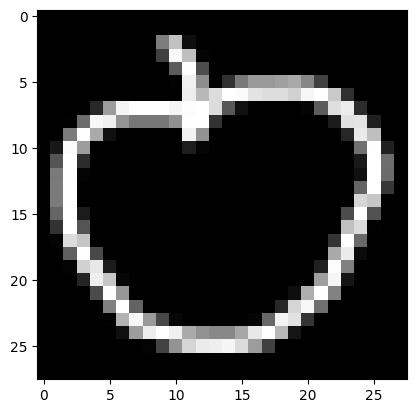

0


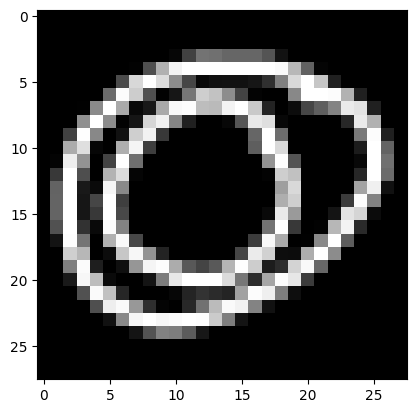

In [6]:
import matplotlib.pyplot as plt

img_tensor = torch.from_numpy(train_images[0])

img_tensor = img_tensor.view(1, 28, 28)
img_tensor = img_tensor.permute(1, 2, 0)
plt.imshow(img_tensor, cmap='gray')
plt.show()
print(train_labels[0])

img_tensor = torch.from_numpy(test_images[0])

img_tensor = img_tensor.view(1, 28, 28)
img_tensor = img_tensor.permute(1, 2, 0)
plt.imshow(img_tensor, cmap='gray')
plt.show()

<class 'numpy.ndarray'>
Total unique classes: 15
Class indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


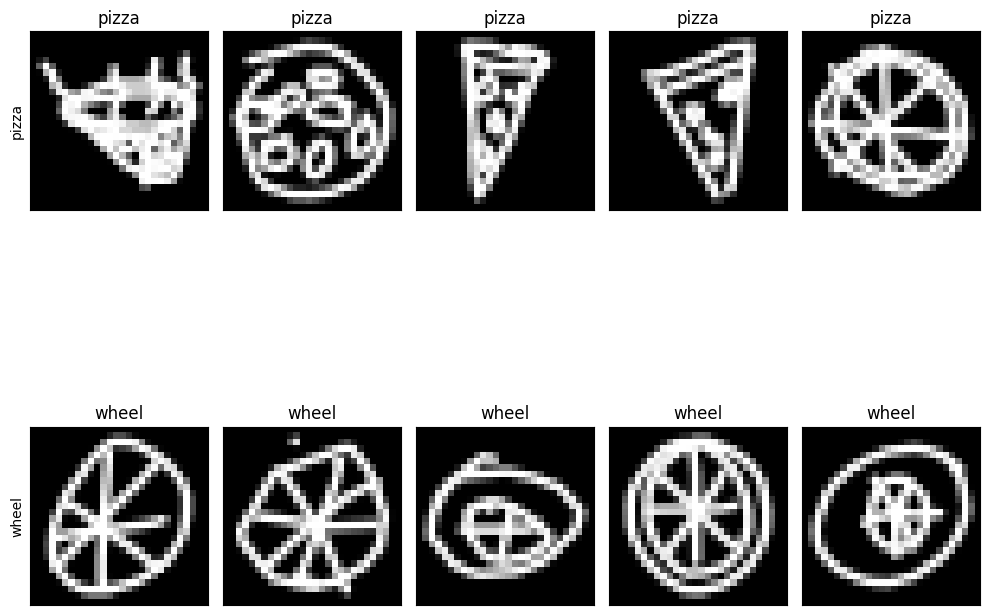

In [7]:
def plot_class_samples(images, labels, class_indices, class_names, sample_per_class=5):
  num_classes = len(class_indices)
  fig, axes = plt.subplots(num_classes, sample_per_class, figsize=(sample_per_class*2, sample_per_class*2))

  for i, class_index in enumerate(class_indices):
    index_list = np.where(labels == class_index)[0]
    selected_indices = np.random.choice(index_list, size=sample_per_class, replace=False)

    for j, index in enumerate(selected_indices):
      img_tensor = images[index].reshape(28, 28)

      ax = axes[i, j]
      ax.imshow(img_tensor, cmap='gray')
      ax.set_title(class_names[class_index])
      if j == 0:
        ax.set_ylabel(class_names[class_index])
      ax.set_xticks([])
      ax.set_yticks([])

  plt.tight_layout()
  plt.show()

target_classes = [9, 14]
class_names = {9: 'pizza', 14: 'wheel'}
print(type(train_labels))

unique_labels = np.unique(train_labels)
print(f"Total unique classes: {len(unique_labels)}")
print(f"Class indices: {unique_labels}")

plot_class_samples(train_images, train_labels, target_classes, class_names)


In [ ]:
HOG_PIXEL_PER_CELL = (4, 4)
HOG_CELL_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

def get_hog_features(images_tensor):
  images_np = images_tensor.cpu().numpy()
  hog_features = []

  for image in images_np:
    image = image.reshape(28, 28)
    fd = hog(image,
             orientations=HOG_ORIENTATIONS,
             pixels_per_cell=HOG_PIXEL_PER_CELL,
             cells_per_block=HOG_CELL_PER_BLOCK, visualize=False)

    hog_features.append(fd)

  return torch.tensor(np.array(hog_features), dtype=torch.float32).to(images_tensor.device)

def calculate_hog_size(image_shape=(28, 28)):
  dummy_img = np.zeros(image_shape)
  fd = hog(dummy_img,
           orientations=HOG_ORIENTATIONS,
           pixels_per_cell=HOG_PIXEL_PER_CELL,
           cells_per_block=HOG_CELL_PER_BLOCK)

  return len(fd)

def apply_augmentation(images_tensor):

  images = images_tensor.view(-1, 1, 28, 28)
  augmented_image = []
  for i in range(images.shape[0]):
    img = images[i]

    angle = random.uniform(-15, 15)
    img = TF.rotate(img, angle)

    shift_x, shift_y = np.random.randint(-2,2), np.random.randint(-2,2)
    img = TF.affine(img, angle=0, translate=(shift_x, shift_y), scale=1.0, shear=0)

    augmented_image.append(img)

    images[i] = img

  return torch.stack(augmented_image).view(-1, 784)

def apply_augmentation_new(images_tensor, image_size=28):
  if images_tensor.dim() != 2 or images_tensor.size(1) != image_size * image_size:
      raise ValueError(f"Input tensor must be 2D with shape (batch_size, {image_size * image_size})")

  images = images_tensor.view(-1, 1, image_size, image_size)
  augmentation = transforms.Compose([
                  transforms.RandomRotation(degrees=12),
                  transforms.RandomAffine(degrees=0, translate=(2/image_size, 2/image_size), scale=(0.95, 1.05),
                                          shear=5),
  ])
  augmented = torch.stack([augmentation(img) for img in images])
  return augmented.view(-1, image_size * image_size)


In [9]:
class WideMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(WideMLP, self).__init__()
    self.fc1 = nn.Linear(input_size, 1048)
    self.fc2 = nn.Linear(1048, 1048)
    self.fc3 = nn.Linear(1048, num_class)

  def forward(self, x):
    x0 = x.view(-1, 784)
    x1 = F.relu(self.fc1(x0))
    x2 = F.relu(self.fc2(x1))
    y_hat = self.fc3(x2)
    return y_hat

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [10]:
class DeepMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(DeepMLP, self).__init__()
    self.input_size = input_size
    self.num_class = num_class
    self.fc1 = nn.Linear(self.input_size, 224)
    self.bn1 = nn.BatchNorm1d(224)

    self.fc2 = nn.Linear(224, 192)
    self.bn2 = nn.BatchNorm1d(192)

    self.fc3 = nn.Linear(192, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.fc4 = nn.Linear(128, 128)
    self.bn4 = nn.BatchNorm1d(128)

    self.fc5 = nn.Linear(128, self.num_class)

    self.drop_light = nn.Dropout(0.15)

  def forward(self, x):
    x = self.drop_light(F.gelu(self.bn1(self.fc1(x))))
    x = self.drop_light(F.gelu(self.bn2(self.fc2(x))))
    x = self.drop_light(F.gelu(self.bn3(self.fc3(x))))
    x = self.drop_light(F.gelu(self.bn4(self.fc4(x))))

    # x = F.gelu(self.bn1(self.fc1(x)))
    # # x = F.gelu(self.bn2(self.fc2(x))))
    # x = F.gelu(self.bn3(self.fc3(x)))
    # x = F.gelu(self.bn4(self.fc4(x)))

    y_hat = self.fc5(x)
    return y_hat

def count_parameters(model):
  for name, module in model.named_modules():
      if list(module.parameters()):
          layer_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
          print(f"Layer: {name}, Trainable Params: {layer_params}")

  return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
def get_gradients_norm(model):
    grad_norms = {}
    for name, p in model.named_parameters():
        if p.grad is not None:
            grad_norms[name] = p.grad.detach().data.norm(2).item()

    return grad_norms

In [12]:
def prepare_images(images, hog_features=False, apply_augmentation=False):

    if apply_augmentation:
      images = apply_augmentation_new(images)

    flat_images = images.view(-1, 784)

    if hog_features:
      hog_features = get_hog_features(images)

      return torch.cat((flat_images, hog_features), dim=1)

    return flat_images

def swa_bn_loader(loader):
  for images, labels in loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    images = prepare_images(images, hog_features=HOG_FEATURES, apply_augmentation=False)
    yield images, labels

def train_one_epoch(model, train_data, criterion, optimizer, grad_history=None):
    model.train()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    for images, labels in train_data:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)
      images =  prepare_images(images, hog_features=HOG_FEATURES, apply_augmentation=AUGMENTATION)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()

      norms = get_gradients_norm(model)

      for name, norm in norms.items():
          grad_history[name].append(norm)

      optimizer.step()

      total_loss += loss.item() * images.size(0)
      _, predicted_classes = torch.max(outputs, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()
      sample_count += images.size(0)

    train_loss = total_loss / sample_count
    train_acc =  100 * accurate_predictions / sample_count

    return train_loss, train_acc

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    with torch.no_grad():
      for images, labels in loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)

          images =  prepare_images(images, hog_features=HOG_FEATURES, apply_augmentation=False)
          outputs = model(images)
          loss = criterion(outputs, labels)

          _, predicted_classes = torch.max(outputs, 1)

          accurate_predictions += (predicted_classes == labels).sum().item()
          total_loss += loss.item() * images.size(0)
          sample_count += images.size(0)

    val_loss = total_loss / sample_count
    val_acc =  100 * accurate_predictions / sample_count

    return val_loss, val_acc

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def confusion_mat(model, loader):
  model.eval()
  all_preds, all_labels = [], []

  with torch.no_grad():
      for images, labels in val_loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)
          images =  prepare_images(images, hog_features=HOG_FEATURES, apply_augmentation=True)

          outputs = model(images.to(DEVICE))
          all_preds.extend(outputs.argmax(1).cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(10,8))
  sns.heatmap(cm, annot=True, fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()


In [14]:
import copy
best_model_weights = None

def train_wide_model(model:nn.Module,
                epochs = 40,
                learning_rate=0.001,
                grad_history=None):

  print(f"Training model for {epochs} epochs")
  print(f"Learning rate: {learning_rate}")


  criterion_cel = nn.CrossEntropyLoss()
  optimizer_adam = optim.Adam(model.parameters(), lr=learning_rate)

  best_val_loss = float('inf')
  epochs_without_improvement = 0
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  for epoch in range(0, epochs):

    # train
    train_loss, train_acc = train_one_epoch(model=model,
                                            train_data=train_loader,
                                            criterion=criterion_cel,
                                            optimizer=optimizer_adam,
                                            grad_history=grad_history)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion_cel)

    # best models
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_model_weights = copy.deepcopy(model.state_dict())
      torch.save(best_model_weights, SAVE_PATH)
      print(f"---> Best model updated at Epoch: {epoch+1} (Validation Loss: {val_loss:.4f})")
    else:
      epochs_without_improvement += 1

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_learning_rate = optimizer_adam.param_groups[0]['lr']
    print(f"Epoch: {epoch+1} (Learning Rate: {current_learning_rate:.6f})")
    print(f"Epoch: {epoch+1}) Training Loss: {train_loss:.4f} Training Accuracy: {train_acc:.2f}% Validation Loss {val_loss:.2f}% Validaion Accuracy:{val_acc:.2f}%")


  model.load_state_dict(best_model_weights)

  torch.save(model.state_dict(), SAVE_PATH)
  print("Training complete. Loaded best model weights")

  print(f"Best model saved at {SAVE_PATH}")
  confusion_mat(model, val_loader)

  return train_losses, train_accs, val_losses, val_accs

In [15]:
from re import VERBOSE
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns
best_model_weights = None

def train_deep_model(model:nn.Module,
                epochs = 40,
                learning_rate=0.001,
                weight_decay=1e-3,
                grad_history=None,
                swa_start= 25,
                swa_lr=2e-5,
                cosine_eta_min=1e-5,
                label_smoothing=0.1,
                early_stopping_patience=0):

  print(f"Training model for {epochs} epochs")
  print(f"Learning rate: {learning_rate}")
  print(f"Weight Decay: {weight_decay}")
  if early_stopping_patience > 0:
    print(f"Early stopping patience: {early_stopping_patience} (before SWA)")

  criterion_cel = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
  optimizer_adam = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam,
                                                   T_max=swa_start if swa_start > 0 else epochs,
                                                   eta_min=cosine_eta_min)

  swa_model = optim.swa_utils.AveragedModel(model)
  swa_scheduler = optim.swa_utils.SWALR(optimizer_adam, swa_lr=swa_lr)

  best_val_loss = float('inf')
  epochs_without_improvement = 0
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  for epoch in range(0, epochs):

    # train
    train_loss, train_acc = train_one_epoch(model=model,
                                            train_data=train_loader,
                                            criterion=criterion_cel,
                                            optimizer=optimizer_adam,
                                            grad_history=grad_history)

    # Validata
    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion_cel)


    # swa
    if swa_start > 0 and epoch >= swa_start:
      swa_model.update_parameters(model)
      swa_scheduler.step()
    else:
      scheduler.step()

    # best models
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      epochs_without_improvement = 0
      best_model_weights = copy.deepcopy(model.state_dict())
      torch.save(best_model_weights, SAVE_PATH)
      print(f"---> Best model updated at Epoch: {epoch+1} (Validation Loss: {val_loss:.4f})")
    else:
      epochs_without_improvement += 1

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_learning_rate = optimizer_adam.param_groups[0]['lr']
    print(f"Epoch: {epoch+1} (Learning Rate: {current_learning_rate:.6f})")
    print(f"Epoch: {epoch+1}) Training Loss: {train_loss:.4f} Training Accuracy: {train_acc:.2f}% Validation Loss {val_loss:.2f}% Validaion Accuracy:{val_acc:.2f}%")

    # early stopping (nly before SWA kicks in)
    if early_stopping_patience > 0 and epoch < swa_start and epochs_without_improvement >= early_stopping_patience:
      print(f"Early stopping triggered at epoch {epoch+1} (no improvement for {early_stopping_patience} epochs)")
      break

  # final swa update
  if swa_start > 0 and epoch >= swa_start:
    print("Finailizing SWA: updating the Batch Normalized stats")
    torch.optim.swa_utils.update_bn(swa_bn_loader(train_loader), swa_model)
    print("Updating the parameters")
    model =  swa_model.module
    best_model_weights = model.state_dict()
  else:
    model.load_state_dict(best_model_weights)

  torch.save(model.state_dict(), SAVE_PATH)
  print("Training complete. Loaded best model weights")

  print(f"Best model saved at {SAVE_PATH}")
  confusion_mat(model, val_loader)

  return train_losses, train_accs, val_losses, val_accs


Layer: , Trainable Params: 1937767
Layer: fc1, Trainable Params: 822680
Layer: fc2, Trainable Params: 1099352
Layer: fc3, Trainable Params: 15735
WideMLP Parameters: 1937767
Training model for 30 epochs
Learning rate: 0.001
---> Best model updated at Epoch: 1 (Validation Loss: 0.9339)
Epoch: 1 (Learning Rate: 0.001000)
Epoch: 1) Training Loss: 1.1092 Training Accuracy: 63.51% Validation Loss 0.93% Validaion Accuracy:69.72%
---> Best model updated at Epoch: 2 (Validation Loss: 0.7964)
Epoch: 2 (Learning Rate: 0.001000)
Epoch: 2) Training Loss: 0.7909 Training Accuracy: 73.99% Validation Loss 0.80% Validaion Accuracy:74.43%
---> Best model updated at Epoch: 3 (Validation Loss: 0.7715)
Epoch: 3 (Learning Rate: 0.001000)
Epoch: 3) Training Loss: 0.6386 Training Accuracy: 78.68% Validation Loss 0.77% Validaion Accuracy:74.72%
---> Best model updated at Epoch: 4 (Validation Loss: 0.7551)
Epoch: 4 (Learning Rate: 0.001000)
Epoch: 4) Training Loss: 0.5298 Training Accuracy: 82.07% Validation L

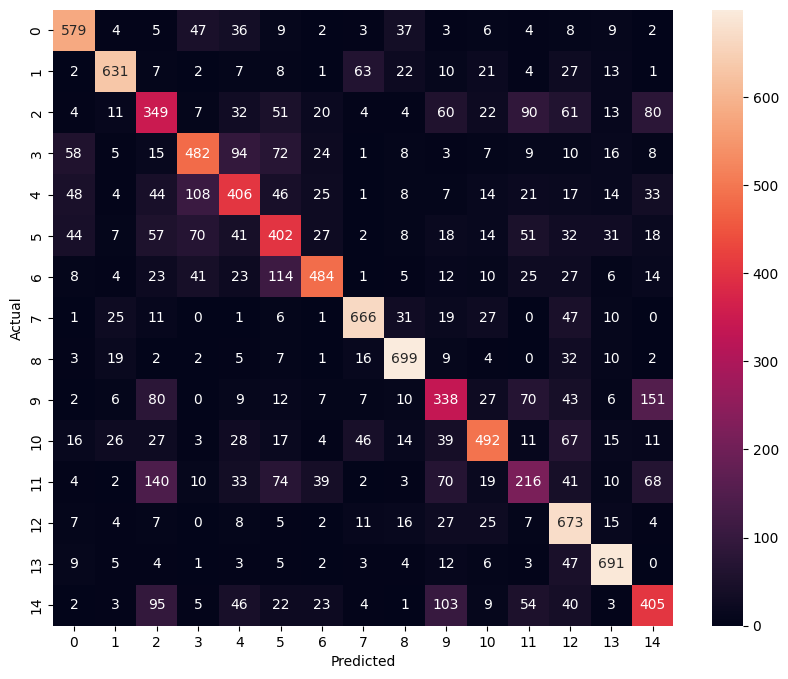

In [16]:

HOG_FEATURES = False
AUGMENTATION = False

input_size = calculate_hog_size() + 784 if HOG_FEATURES else 784
wide_model = WideMLP(input_size).to(DEVICE)
print(f"WideMLP Parameters: {count_parameters(wide_model)}")

grad_history = {name:[] for name, _ in wide_model.named_parameters()}
d_train_losses, d_train_acc, d_val_losses, d_val_acc = train_wide_model(wide_model,
                                                        epochs=EPOCHS,
                                                        learning_rate=LR,
                                                        grad_history=grad_history)


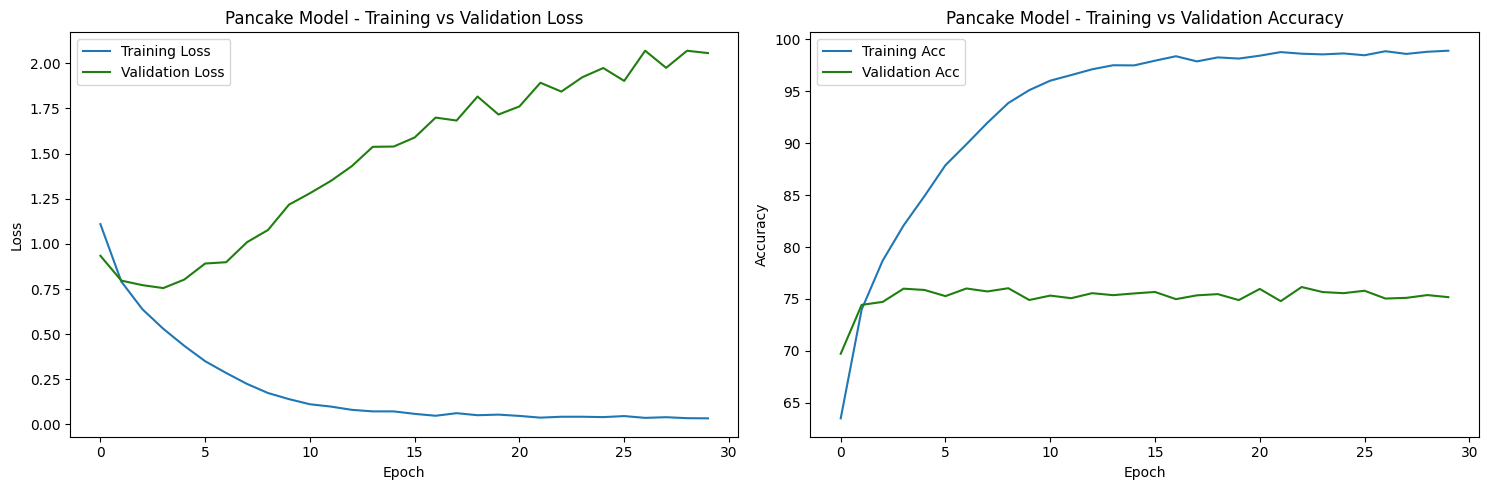

In [17]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(d_train_losses, label='Training Loss', color='#1f77b4')
plt.plot(d_val_losses, label='Validation Loss', color='#1f7f0e')
plt.title('Pancake Model - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(d_train_acc, label='Training Acc', color='#1f77b4')
plt.plot(d_val_acc, label='Validation Acc', color='#1f7f0e')
plt.title('Pancake Model - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

2080
Layer: , Trainable Params: 553839
Layer: fc1, Trainable Params: 466144
Layer: bn1, Trainable Params: 448
Layer: fc2, Trainable Params: 43200
Layer: bn2, Trainable Params: 384
Layer: fc3, Trainable Params: 24704
Layer: bn3, Trainable Params: 256
Layer: fc4, Trainable Params: 16512
Layer: bn4, Trainable Params: 256
Layer: fc5, Trainable Params: 1935
DeepMLP Parameters: 553839
Training model for 30 epochs
Learning rate: 0.001
Weight Decay: 2e-05
Early stopping patience: 15 (before SWA)
---> Best model updated at Epoch: 1 (Validation Loss: 0.8778)
Epoch: 1 (Learning Rate: 0.000997)
Epoch: 1) Training Loss: 1.2462 Training Accuracy: 65.94% Validation Loss 0.88% Validaion Accuracy:78.97%
---> Best model updated at Epoch: 2 (Validation Loss: 0.8493)
Epoch: 2 (Learning Rate: 0.000990)
Epoch: 2) Training Loss: 1.0139 Training Accuracy: 73.79% Validation Loss 0.85% Validaion Accuracy:79.77%
---> Best model updated at Epoch: 3 (Validation Loss: 0.7961)
Epoch: 3 (Learning Rate: 0.000977)
Epoc

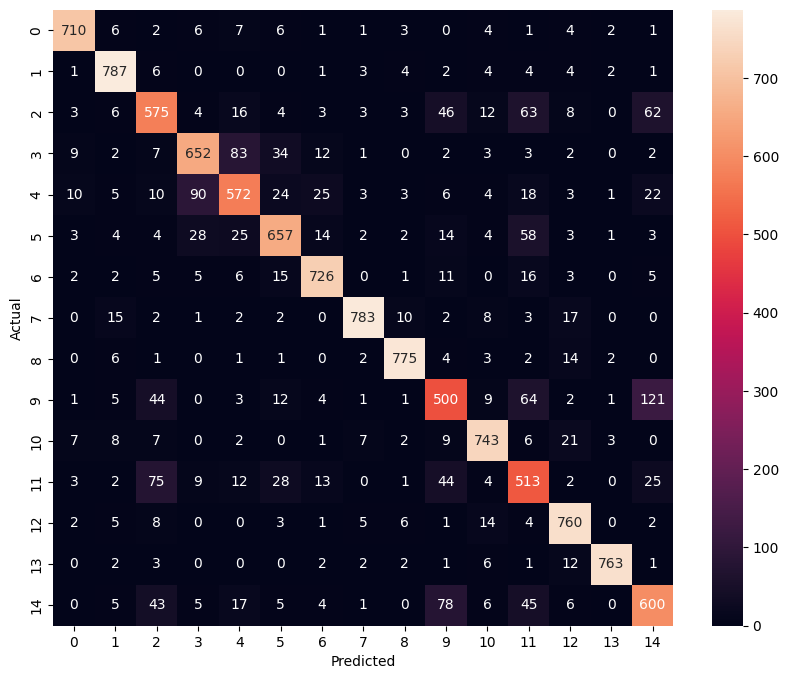

In [18]:

HOG_FEATURES = True
AUGMENTATION = True

input_size = calculate_hog_size() + 784 if HOG_FEATURES else 784

print(input_size)
deep_model = DeepMLP(input_size).to(DEVICE)
print(f"DeepMLP Parameters: {count_parameters(deep_model)}")

grad_history = {name:[] for name, _ in deep_model.named_parameters()}
t_train_losses, t_train_acc, t_val_losses, t_val_acc = train_deep_model(deep_model,
                                                        epochs=EPOCHS,
                                                        learning_rate=LR,
                                                        weight_decay=L2_REGULARIZATION,
                                                        grad_history=grad_history,
                                                        swa_start=SWA_START,
                                                        cosine_eta_min=COSINE_ETA_MIN,
                                                        label_smoothing=LABEL_SMOOTHING,
                                                        early_stopping_patience=EARLY_STOPPING_PATIENCE)



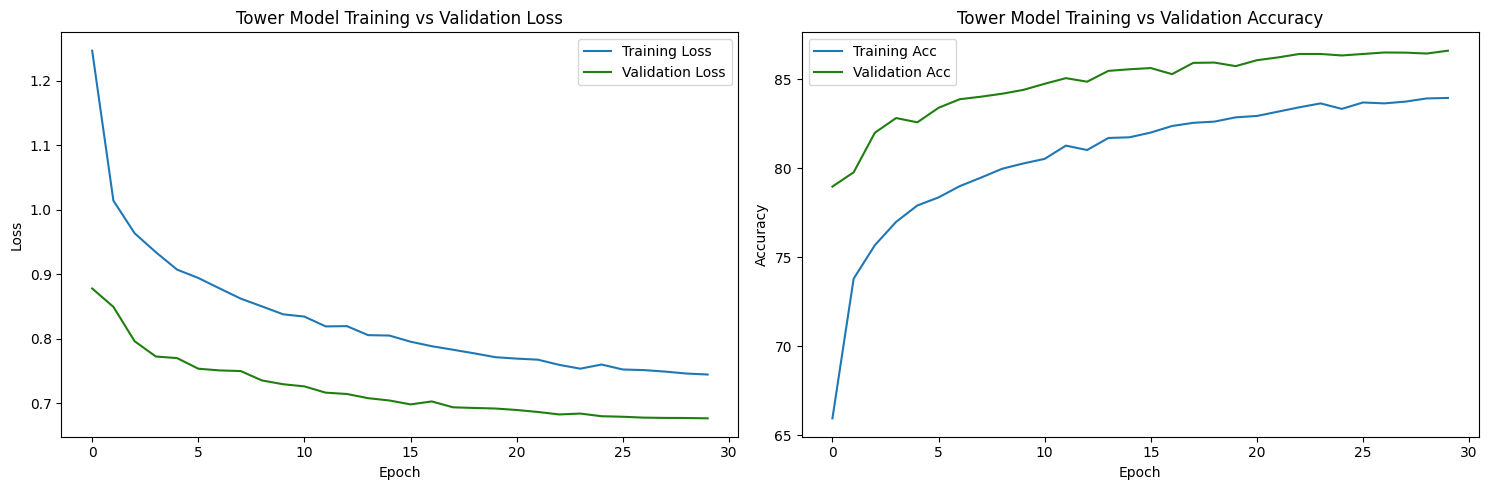

In [19]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(t_train_losses, label='Training Loss', color='#1f77b4')
plt.plot(t_val_losses, label='Validation Loss', color='#1f7f0e')
plt.title('Tower Model Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_train_acc, label='Training Acc', color='#1f77b4')
plt.plot(t_val_acc, label='Validation Acc', color='#1f7f0e')
plt.title('Tower Model Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

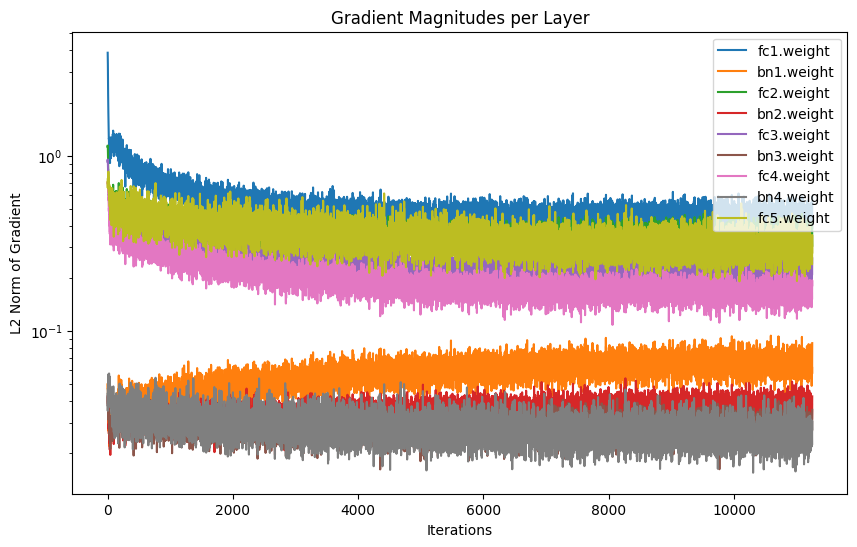

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, grads in grad_history.items():
    if 'weight' in name:
        plt.plot(grads, label=name)

plt.title("Gradient Magnitudes per Layer")
plt.xlabel("Iterations")
plt.ylabel("L2 Norm of Gradient")
plt.legend()
plt.yscale('log')
plt.show()

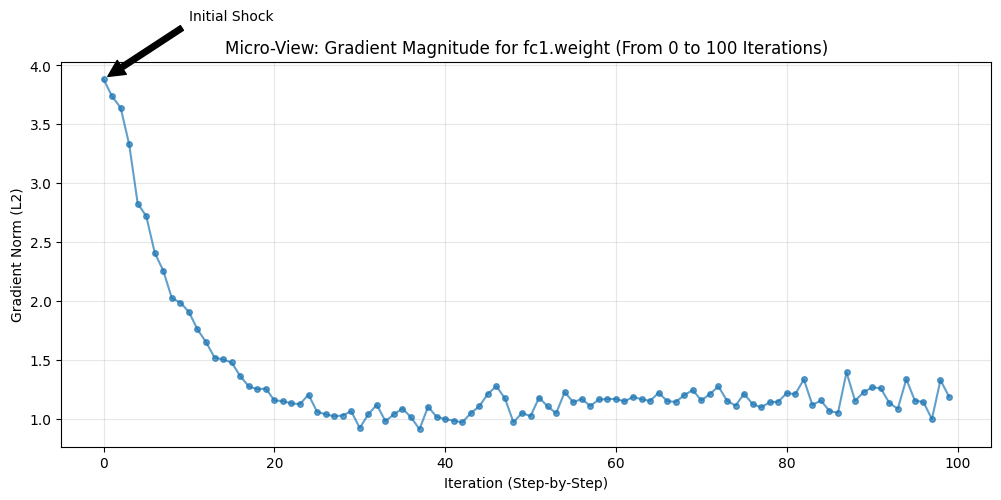

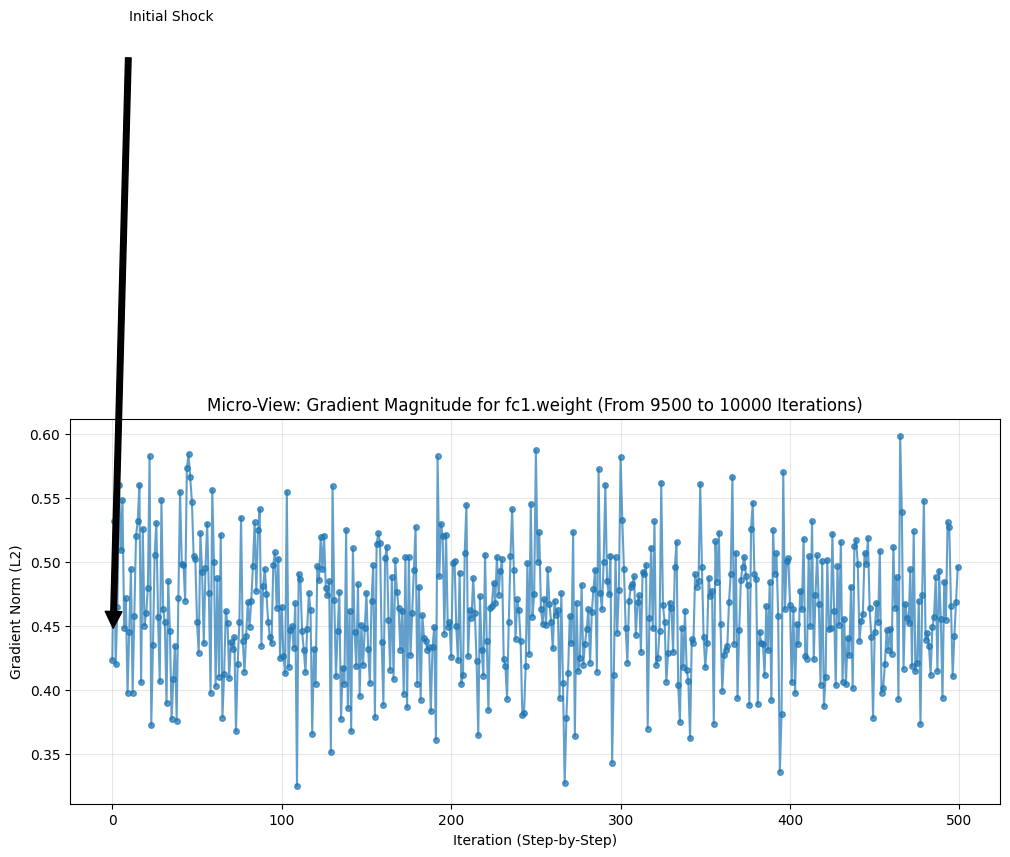

In [24]:
import matplotlib.pyplot as plt

def plot_gradient_zoom(grad_history, layer_name='fc1.weight', limit_start=0, limit_end=100):
    data = grad_history[layer_name][limit_start:limit_end]

    plt.figure(figsize=(12, 5))
    plt.plot(data, marker='o', linestyle='-', markersize=4, color='#1f77b4', alpha=0.7)

    plt.title(f"Micro-View: Gradient Magnitude for {layer_name} (From {limit_start} to {limit_end} Iterations)")
    plt.xlabel("Iteration (Step-by-Step)")
    plt.ylabel("Gradient Norm (L2)")
    plt.grid(True, alpha=0.3)

    plt.annotate('Initial Shock', xy=(0, data[0]), xytext=(10, data[0]+0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()

plot_gradient_zoom(grad_history)

plot_gradient_zoom(grad_history, limit_start=9500, limit_end=10000)


In [25]:
def run_predictions(model, loader):
  print(f"Evaluation on Test Set:")

  all_predictions = []
  model.eval()
  with torch.no_grad():
    for batch in loader:
      images = batch[0].to(DEVICE)

      images = prepare_images(images, hog_features=HOG_FEATURES, apply_augmentation=False)
      outputs = model(images)
      _, predictions = torch.max(outputs, 1)
      all_predictions.extend(predictions.cpu().numpy().tolist())

  return all_predictions

predictions = run_predictions(deep_model, test_loader)
predictions_string = ",".join(map(str, predictions))

output_file = "predictions.txt"

with open(output_file, "w") as f:
    f.write(predictions_string)

print(f"Predictions saved to {output_file}")


Evaluation on Test Set:
Predictions saved to predictions.txt
